# Experiment 7 Analysis
Automated analysis generated by Stage 06.


In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import sys

# Ensure we can import from s06_analysis
sys.path.append(str(Path.cwd().parent.parent))
from s06_analysis.src.io.result_flattener import ResultFlattener

# Configure seaborn styling
sns.set_theme(style="whitegrid")

# Load flattened data
DATA_PATH = Path("../input/flattened_results.csv")
raw_df = pd.read_csv(DATA_PATH)
flattener = ResultFlattener()
df, topology_df = flattener.flatten(raw_df)

print(f"Loaded {len(df)} records.")
df.head()


Loaded 361 records.


,runtimes,deletion_ratio,marginals_error,tvd_2way,ml_accuracy,violations,loss_function,marginal_generation_quality,marginal_selection_quality,dataset_name,...,ml_acc_repaired,ml_acc_synthetic,ml_acc_logistic_regression_repaired,ml_acc_logistic_regression_synthetic,ml_acc_random_forest_repaired,ml_acc_random_forest_synthetic,ml_acc_mlp_repaired,ml_acc_mlp_synthetic,loss_marginal_repaired,loss_marginal_synthetic
0,{'repair': 1.4529247283935547},0.00548,"{'synthetic_avg': 7740000.25739977, 'repaired_...","{'synthetic_avg': 0.02806918758573059, 'repair...",{'synthetic': {'logistic_regression': 0.620883...,"{'private': 0, 'synthetic': 227816, 'repaired'...","{'synthetic': {'total': 0.4968613761267989, 's...",{'avg_relative_error': 1.5151305911681752},"{'precision_at_k': 0.0, 'overlap_count': 0, 'k...",census_loaded_census_mst_eps0.3_syn_repaired,...,0.597963,0.598572,0.620884,0.620884,0.554299,0.554253,0.618705,0.620579,0.008497,0.008448
1,{'repair': 1.1642861366271973},0.00552,"{'synthetic_avg': 7760000.25754984, 'repaired_...","{'synthetic_avg': 0.028596279036071346, 'repai...",{'synthetic': {'logistic_regression': 0.620884...,"{'private': 0, 'synthetic': 174875, 'repaired'...","{'synthetic': {'total': 0.4968493761267989, 's...",{'avg_relative_error': 1.5151305911681752},"{'precision_at_k': 0.0, 'overlap_count': 0, 'k...",census_loaded_census_mst_eps0.4_syn_repaired,...,0.598167,0.598265,0.620883,0.620884,0.553410,0.553779,0.620209,0.620133,0.008516,0.008424
2,{'repair': 4768.702855825424},0.10728,"{'synthetic_avg': 2640000.2654167376, 'repaire...","{'synthetic_avg': 0.04356608093346673, 'repair...",{'synthetic': {'logistic_regression': 0.822120...,"{'private': 0, 'synthetic': 24596738, 'repaire...","{'synthetic': {'total': -0.008915789188471874,...",{'avg_relative_error': 0.7874489316177482},"{'precision_at_k': 0.0, 'overlap_count': 0, 'k...",adult_loaded_adult_aim_eps0.4_syn_repaired,...,0.832303,0.832781,0.822796,0.822120,0.834384,0.835040,0.839728,0.841182,0.008728,0.005878
3,{'repair': 0.5193781852722168},0.00098,"{'synthetic_avg': 8010000.242512947, 'repaired...","{'synthetic_avg': 0.010160325647092957, 'repai...",{'synthetic': {'logistic_regression': 0.620134...,"{'private': 0, 'synthetic': 62444, 'repaired': 0}","{'synthetic': {'total': 0.495763163374701, 'si...",{'avg_relative_error': 1.5151305911681752},"{'precision_at_k': 0.0, 'overlap_count': 0, 'k...",census_loaded_census_aim_eps1.0_syn_repaired,...,0.601468,0.601109,0.620131,0.620134,0.563810,0.563081,0.620465,0.620111,0.006260,0.006251
4,{'repair': 1885.5718324184418},0.04616,"{'synthetic_avg': 2500000.285790182, 'repaired...","{'synthetic_avg': 0.04787805895394478, 'repair...",{'synthetic': {'logistic_regression': 0.806662...,"{'private': 0, 'synthetic': 19917732, 'repaire...","{'synthetic': {'total': -0.008564289754722502,...",{'avg_relative_error': 0.7874489316177482},"{'precision_at_k': 0.0, 'overlap_count': 0, 'k...",adult_loaded_adult_mst_eps0.6_syn_repaired,...,0.801332,0.801537,0.806621,0.806662,0.795135,0.795217,0.802240,0.802731,0.007477,0.006581


## 1. Deletion Ratio by Dataset
Analyzes the deletion ratio using repair algorithm as hue and synthesizer as style.


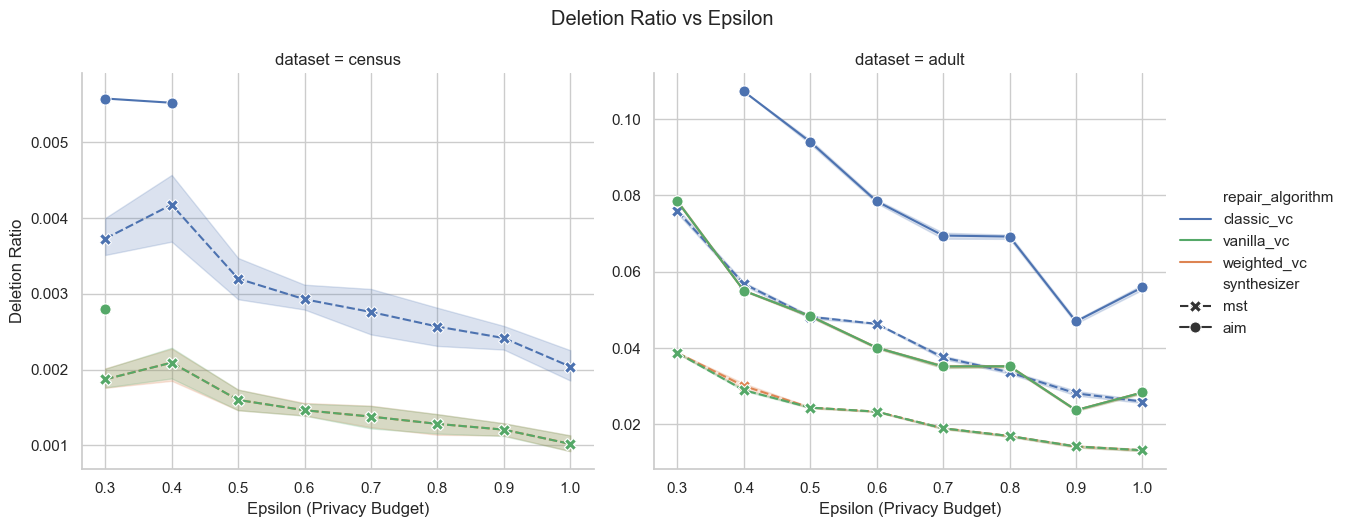

In [10]:
g = sns.FacetGrid(df, col="dataset", sharey=False, height=5, aspect=1.2)
g.map_dataframe(sns.lineplot, x="epsilon", y="deletion_ratio", hue="repair_algorithm", style="synthesizer", markers=True, markersize=8)
g.add_legend()
g.set_axis_labels("Epsilon (Privacy Budget)", "Deletion Ratio")
g.fig.suptitle("Deletion Ratio vs Epsilon", y=1.05)
plt.show()


## 2. Marginals Error


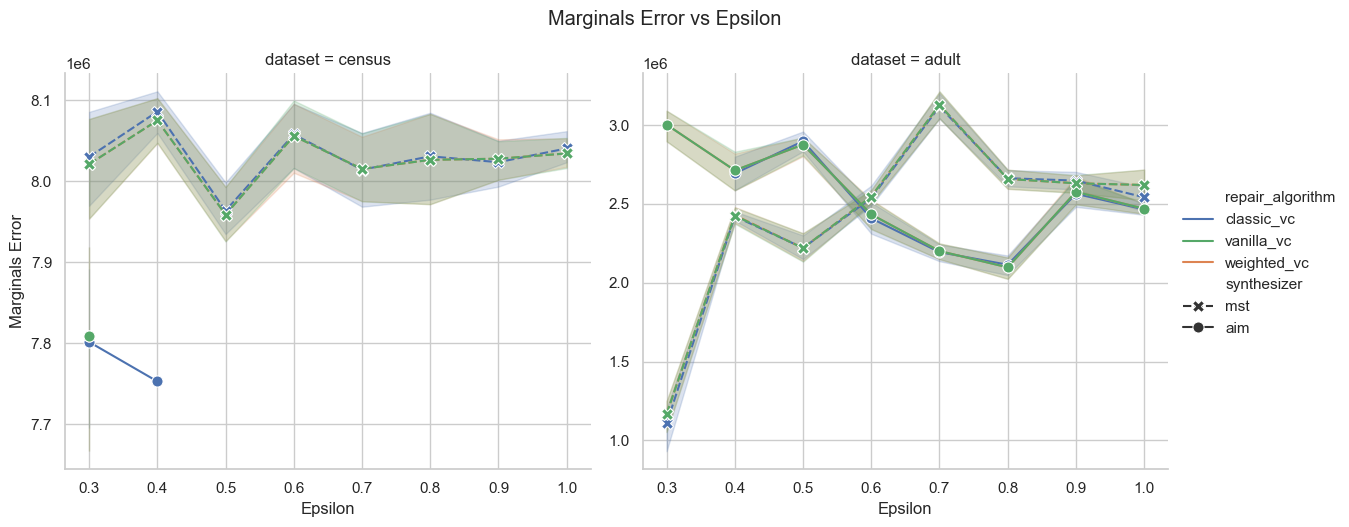

In [11]:
g = sns.FacetGrid(df, col="dataset", sharey=False, height=5, aspect=1.2)
g.map_dataframe(sns.lineplot, x="epsilon", y="marginals_error_repaired", hue="repair_algorithm", style="synthesizer", markers=True, markersize=8)
g.add_legend()
g.set_axis_labels("Epsilon", "Marginals Error")
g.fig.suptitle("Marginals Error vs Epsilon", y=1.05)
plt.show()


## 3. Marginals Loss


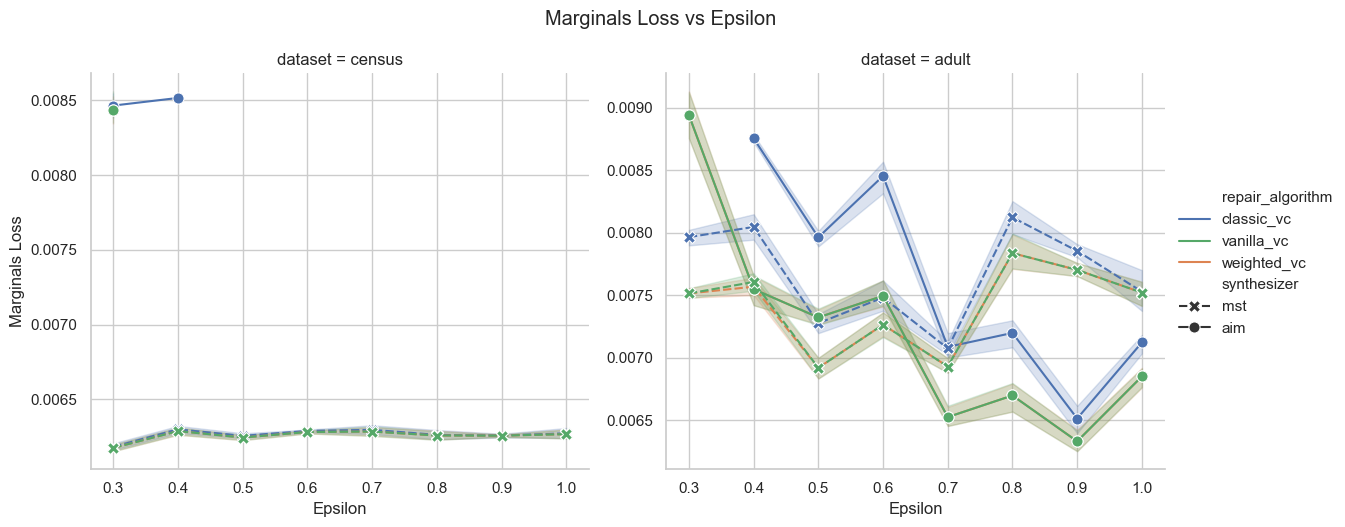

In [12]:
g = sns.FacetGrid(df, col="dataset", sharey=False, height=5, aspect=1.2)
g.map_dataframe(sns.lineplot, x="epsilon", y="loss_marginal_repaired", hue="repair_algorithm", style="synthesizer", markers=True, markersize=8)
g.add_legend()
g.set_axis_labels("Epsilon", "Marginals Loss")
g.fig.suptitle("Marginals Loss vs Epsilon", y=1.05)
plt.show()


## 4. Total Variation Distance (TVD)


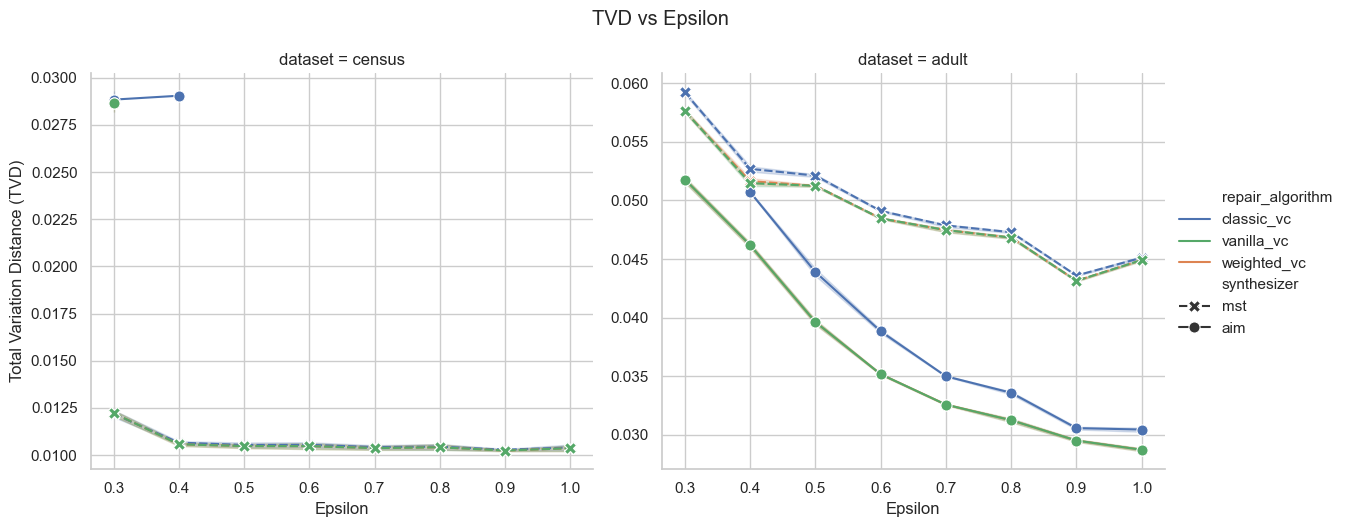

In [13]:
g = sns.FacetGrid(df, col="dataset", sharey=False, height=5, aspect=1.2)
g.map_dataframe(sns.lineplot, x="epsilon", y="tvd_repaired", hue="repair_algorithm", style="synthesizer", markers=True, markersize=8)
g.add_legend()
g.set_axis_labels("Epsilon", "Total Variation Distance (TVD)")
g.fig.suptitle("TVD vs Epsilon", y=1.05)
plt.show()


## 5. Machine Learning Accuracy


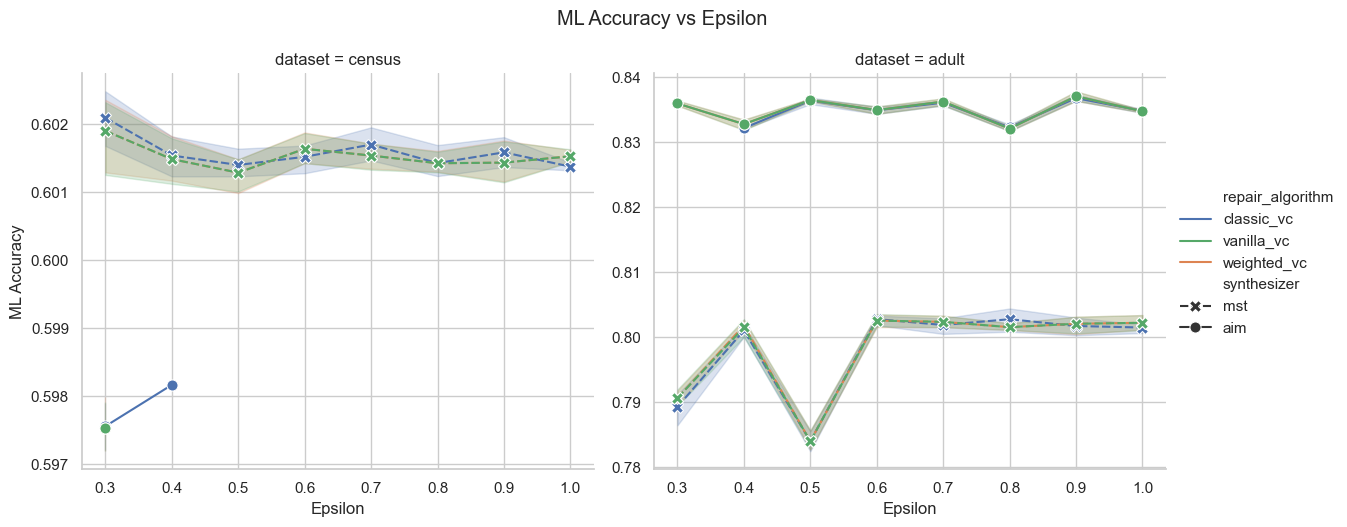

In [14]:
g = sns.FacetGrid(df, col="dataset", sharey=False, height=5, aspect=1.2)
g.map_dataframe(sns.lineplot, x="epsilon", y="ml_acc_repaired", hue="repair_algorithm", style="synthesizer", markers=True, markersize=8)
g.add_legend()
g.set_axis_labels("Epsilon", "ML Accuracy")
g.fig.suptitle("ML Accuracy vs Epsilon", y=1.05)
plt.show()


## 6. Runtime


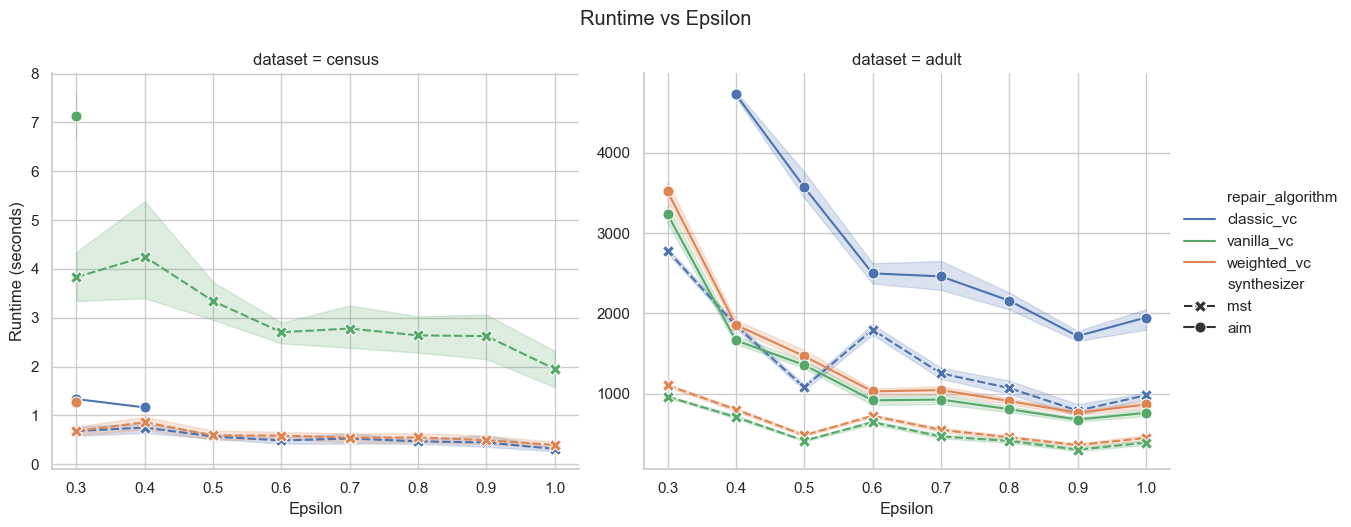

In [15]:
g = sns.FacetGrid(df, col="dataset", sharey=False, height=5, aspect=1.2)
g.map_dataframe(sns.lineplot, x="epsilon", y="repair_runtime", hue="repair_algorithm", style="synthesizer", markers=True, markersize=8)
g.add_legend()
g.set_axis_labels("Epsilon", "Runtime (seconds)")
g.fig.suptitle("Runtime vs Epsilon", y=1.05)
plt.show()
